# Volatility Surface Calibration Engine 

In [24]:
import os, sys
sys.path.insert(0, os.path.abspath('../src'))
sys.path.insert(0, os.path.abspath('../src/vol_surface'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bs
import implied_vol as iv
import data
import svi
import arbitrage as arb
import ssvi
import surface
import global_essvi as ge

%matplotlib inline
np.set_printoptions(precision=6, suppress=True)

## Step 1 — Data ingestion + smile extraction (`data.py`)

Pulls the live BTC option chain from Deribit's public API, filters illiquid quotes, and converts mids to implied vol.

In [25]:
CURRENCY = 'BTC'
raw = data.fetch_book_summary(CURRENCY)
chain = data.build_chain(raw)
print(f"{len(chain)} liquid quotes across {chain['expiry'].nunique()} expiries")
chain.head()

713 liquid quotes across 12 expiries


,strike,expiry,T,forward,mid_iv,weight,option_type,bid,ask,mid
0,72000.0,2026-09-07 08:00:00+00:00,0.001871,79623.59,0.717128,0.000005,C,7404.993870,7842.923615,7623.958742
1,73000.0,2026-09-07 08:00:00+00:00,0.001871,79623.59,0.985662,0.000006,C,6449.510790,6847.628740,6648.569765
2,75500.0,2026-09-07 08:00:00+00:00,0.001871,79623.47,0.611565,0.000006,C,3941.361765,4339.479115,4140.420440
3,76500.0,2026-09-07 08:00:00+00:00,0.001871,79623.47,0.355653,0.000005,C,2906.256655,3344.185740,3125.221198
4,77500.0,2026-09-07 08:00:00+00:00,0.001871,79623.47,0.297008,0.000013,C,1990.586750,2269.268895,2129.927823


In [26]:
# acceptance criteria: no NaNs/negative vols after filtering
assert chain.isna().sum().sum() == 0
assert (chain['mid_iv'] > 0).all()

counts = chain.groupby('expiry').size().sort_values(ascending=False)
print(counts)

expiry
2026-12-25 08:00:00+00:00    102
2027-03-26 08:00:00+00:00     96
2027-06-25 08:00:00+00:00     95
2026-10-30 08:00:00+00:00     94
2026-11-27 08:00:00+00:00     89
2026-09-25 08:00:00+00:00     76
2026-09-18 08:00:00+00:00     35
2026-09-10 08:00:00+00:00     35
2026-09-11 08:00:00+00:00     34
2026-09-09 08:00:00+00:00     24
2026-09-08 08:00:00+00:00     19
2026-09-07 08:00:00+00:00     14
dtype: int64


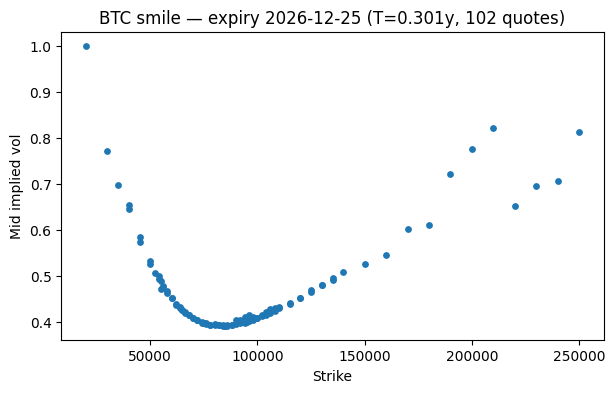

In [27]:
# smile for the most liquid expiry 
biggest_expiry = counts.idxmax()
slice_ = chain[chain['expiry'] == biggest_expiry].sort_values('strike')

plt.figure(figsize=(7,4))
plt.scatter(slice_['strike'], slice_['mid_iv'], s=15)
plt.xlabel('Strike'); plt.ylabel('Mid implied vol')
plt.title(f'{CURRENCY} smile — expiry {biggest_expiry.date()} (T={slice_["T"].iloc[0]:.3f}y, {len(slice_)} quotes)')
plt.show()

## Step 2 — SVI slice fit (`svi.py`)

Fit the raw SVI parameterization to the smile above, in total-variance space.

Fit raw SVI first, check arbitrage after. The SVI 5-parameter fit is not arbitrage-free constrained, so on live data it can land in an optimal curve that violates butterfly arbitrage 

SVIParams(a=np.float64(-0.10303683264740421), b=np.float64(0.2316286263346327), rho=np.float64(-0.3020859996292366), m=np.float64(-0.19225815188132453), sigma=np.float64(0.6715700902428224))
weighted RMSE (total variance): 0.0011360504225856713
butterfly check: passed


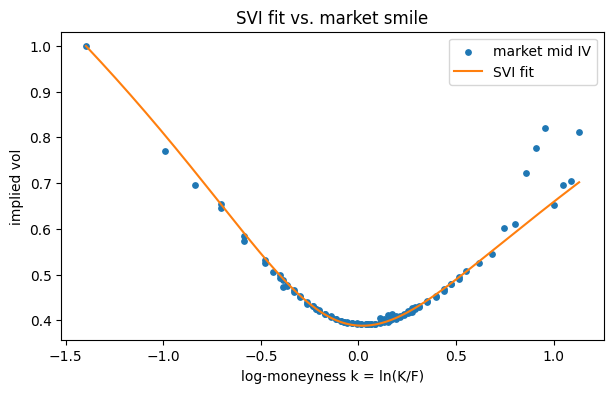

In [28]:
F = float(slice_['forward'].iloc[0])
T_slice = float(slice_['T'].iloc[0])
k = np.log(slice_['strike'].to_numpy() / F)

fit_result = svi.fit_svi_slice(k, slice_['mid_iv'].to_numpy(), slice_['weight'].to_numpy(), T_slice, validate=False)
print(fit_result.params)
print('weighted RMSE (total variance):', fit_result.weighted_rmse)
try:
    arb.check_butterfly(fit_result.params)
    print('butterfly check: passed')
except arb.ArbitrageError as exc:
    print('butterfly check: FAILED (unconstrained fit on today\'s smile) --', exc)

k_grid = np.linspace(k.min(), k.max(), 200)
fitted_iv = fit_result.params.implied_vol(k_grid, T_slice)

plt.figure(figsize=(7,4))
plt.scatter(k, slice_['mid_iv'], s=15, label='market mid IV')
plt.plot(k_grid, fitted_iv, color='C1', label='SVI fit')
plt.xlabel('log-moneyness k = ln(K/F)'); plt.ylabel('implied vol')
plt.legend(); plt.title('SVI fit vs. market smile')
plt.show()

## Step 3— No-arbitrage validation (`arbitrage.py`) on SVI slice above

### Butterfly check

A slice is free of butterfly arbitrage iff **both** (Gatheral & Jacquier, 2013, Lemma 2.2):

1. `g(k) >= 0` for all `k` 
2. `lim_{k->+inf} d+(k) = -inf`, where `d+(k) = -k/sqrt(w(k)) + sqrt(w(k))/2`

`check_wing_condition` tests condition (ii) as the parameter bound `b*(1+rho) < 2` rather
than by evaluating the limit. **This is the limit
in closed form.** Writing `c := b(1+rho)`, the tail expansion `w(k) ~ c*k + (a - c*m)` gives

```
d+(k) = [(c-2)k + (a-c*m)] / (2*sqrt(c*k + a-c*m))  ->  L*sqrt(k),   L := (c-2)/(2*sqrt(c))
```

so `lim d+ = -inf` **iff** `L < 0` **iff**
`c < 2`. 

This bound is **not stated in the paper for raw SVI**. The paper gives Lemma
2.2's limit, and only puts a number on an asymptotic slope in Remark 4.3, for SSVI. 

In [29]:
# condition (i): g(k) >= 0 on the grid 
g_vals = arb.g_function(arb.DEFAULT_K_GRID, fit_result.params)
print('min g(k) over the check grid:', g_vals.min(),
      '-> condition (i) HOLDS' if g_vals.min() >= 0 else '-> VIOLATION')

min g(k) over the check grid: 0.08755105044553015 -> condition (i) HOLDS


In [30]:
# condition (ii): lim_{k->+inf} d+(k) = -inf, tested as an actual limit
p = fit_result.params
c_slope = p.b * (1 + p.rho)
L_closed = (c_slope - 2) / (2 * np.sqrt(c_slope))

k_probe = np.array([1e4, 1e8, 1e12, 1e16, 1e20])
ratio = arb.d_plus(k_probe, p) / np.sqrt(k_probe)

print(f'\nwing slope c = b(1+rho) = {c_slope:.6f}')
print('d+(k)/sqrt(k), which must converge to L = (c-2)/(2*sqrt(c)):')
for k_i, r_i in zip(k_probe, ratio):
    print(f'  k={k_i:.0e}:  {r_i:+.8e}')
print(f'  closed-form L = {L_closed:+.8e}   (measured matches to '
      f'{abs(ratio[-1] - L_closed):.1e})')
print(f'-> L {"<" if L_closed < 0 else ">="} 0, so lim d+(k) = '
      f'{"-inf: condition (ii) HOLDS" if L_closed < 0 else "+inf: VIOLATION"}')


wing slope c = b(1+rho) = 0.161657
d+(k)/sqrt(k), which must converge to L = (c-2)/(2*sqrt(c)):
  k=1e+04:  -2.28618240e+00
  k=1e+08:  -2.28612258e+00
  k=1e+12:  -2.28612257e+00
  k=1e+16:  -2.28612257e+00
  k=1e+20:  -2.28612257e+00
  closed-form L = -2.28612257e+00   (measured matches to 0.0e+00)
-> L < 0, so lim d+(k) = -inf: condition (ii) HOLDS


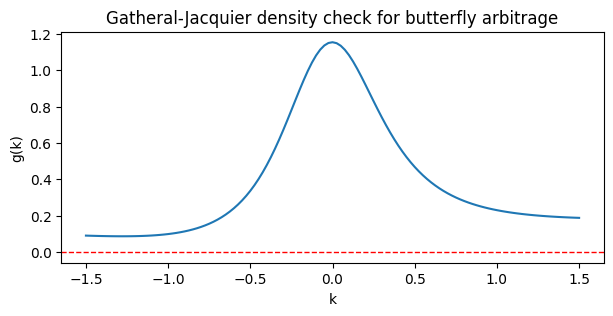

In [31]:
plt.figure(figsize=(7, 3))
plt.plot(arb.DEFAULT_K_GRID, g_vals)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('k'); plt.ylabel('g(k)')
plt.title('Gatheral-Jacquier density check for butterfly arbitrage')
plt.show()

### Calendar check (`check_calendar`) for two *most liquid* expiries

Total variance `w(k, T)` must be non-decreasing in `T` at fixed log-moneyness
`k`. 

`arbitrage.check_calendar` takes a list of `(T, SVIParams)` pairs, sorts them by `T`, and checks every
**adjacent** pair on a shared `k` grid. It's run
once after every expiry has been SVI-fitted -- unlike the
butterfly check, it needs neighboring slices, so it can't run per-slice.



T=0.3005 (102 quotes): SVIParams(a=np.float64(-0.10303683264740421), b=np.float64(0.2316286263346327), rho=np.float64(-0.3020859996292366), m=np.float64(-0.19225815188132453), sigma=np.float64(0.6715700902428224))
T=0.5498 (96 quotes): SVIParams(a=np.float64(-0.2584727158639486), b=np.float64(0.32017570691159003), rho=np.float64(-0.1634051617714231), m=np.float64(-0.12885569741537112), sigma=np.float64(1.1005019020698945))


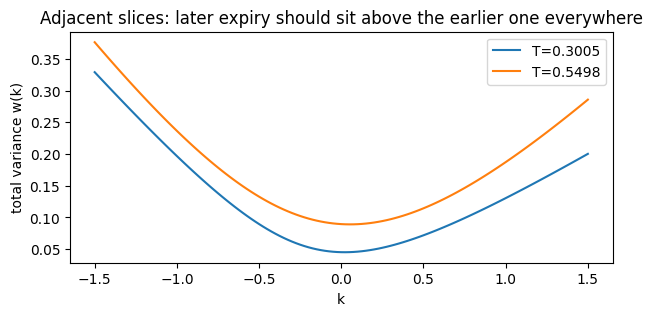

calendar check passed: total variance is non-decreasing across these expiries


In [32]:
# fit the two most liquid expiries and check the pair
most_liquid_expiries = counts.nlargest(2).index
two_T = sorted(chain[chain['expiry'].isin(most_liquid_expiries)]['T'].unique())

calendar_slices = []
for T_i in two_T:
    g_i = chain[chain['T'] == T_i]
    F_i = float(g_i['forward'].iloc[0])
    k_i = np.log(g_i['strike'].to_numpy() / F_i)
    res_i = svi.fit_svi_slice(k_i, g_i['mid_iv'].to_numpy(), g_i['weight'].to_numpy(), T_i, validate=False)
    calendar_slices.append((T_i, res_i.params))
    print(f"T={T_i:.4f} ({len(g_i)} quotes): {res_i.params}")

w_curves = [svi.raw_svi(arb.DEFAULT_K_GRID, *params.as_array()) for _, params in calendar_slices]
plt.figure(figsize=(7,3))
for (T_i, _), w_i in zip(calendar_slices, w_curves):
    plt.plot(arb.DEFAULT_K_GRID, w_i, label=f'T={T_i:.4f}')
plt.xlabel('k'); plt.ylabel('total variance w(k)'); plt.legend()
plt.title('Adjacent slices: later expiry should sit above the earlier one everywhere')
plt.show()

try:
    arb.check_calendar(calendar_slices)
    print('calendar check passed: total variance is non-decreasing across these expiries')
except arb.ArbitrageError as e:
    print('calendar arbitrage detected:', e)

### Exact calendar check (`check_calendar_exact`)

`check_calendar` above evaluates `w2 - w1` on `DEFAULT_K_GRID` --  but an arbitrage violation narrower than that spacing can fall entirely between two grid
points and go undetected. 

`arbitrage.check_calendar_exact`  finds
every *exact* intersection of two raw SVI slices via the closed-form
quartic from Gatheral & Jacquier (2013, Lemma 3.3) -- `find_slice_crossings`
solves `w(k;chi1) = w(k;chi2)` exactly (up to squaring-induced spurious
roots, filtered back out against the original equation).

First: run both checks on the live pair already fitted above (should
agree). Then: a constructed experimental pair whose two crossings narrower than the grid spacing -- so `check_calendar`
misses the arbitrage entirely while `check_calendar_exact` catches it
exactly.

In [33]:
# run the exact check on the same live pair fitted above, and confirm it agrees
crossings_live = arb.find_slice_crossings(calendar_slices[0][1], calendar_slices[1][1])
print('exact crossings between the two live slices:', crossings_live)

try:
    arb.check_calendar_exact(calendar_slices)
    print('check_calendar_exact: passed (agrees with check_calendar above)')
except arb.ArbitrageError as e:
    print('check_calendar_exact: detected arbitrage ->', e)

exact crossings between the two live slices: []
check_calendar_exact: passed (agrees with check_calendar above)


exact crossings: [0.034474238507984124, 0.03911931052575252] (gap = 0.0046, grid spacing = 0.0250)


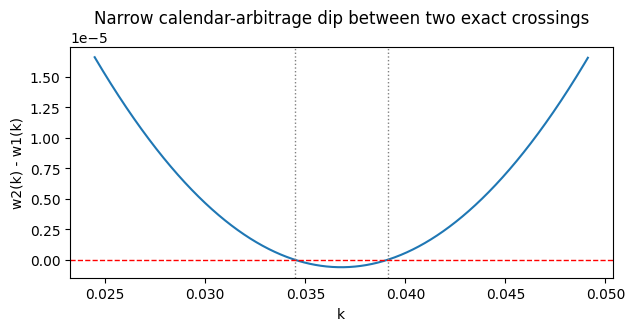

check_calendar (grid):        PASSED -- missed the arbitrage
check_calendar_exact (quartic): correctly caught it -> calendar arbitrage (exact) between T=0.1000 and T=0.5000: total variance ordering violated at k=0.0346 (drop 5.173e-08); slice crossings at k=[0.034474238507984124, 0.03911931052575252]


In [34]:
# A pair whose slices cross twice, ~0.0046 apart in k (found by random search by Claude) --
# narrow enough to slip between DEFAULT_K_GRID's ~0.025-wide steps entirely.
narrow_p1 = svi.SVIParams(a=0.02236232183296754, b=0.13667759465470686, rho=0.03925944666914394,
                           m=-0.012900631505364302, sigma=0.10832690341116893)
narrow_p2 = svi.SVIParams(a=0.02081207476543416, b=0.15249346064086547, rho=0.07957366224968813,
                           m=-0.0013092781972601879, sigma=0.10924503147696951)
narrow_pair = [(0.1, narrow_p1), (0.5, narrow_p2)]

crossings = arb.find_slice_crossings(narrow_p1, narrow_p2)
print('exact crossings:', crossings, f'(gap = {crossings[1]-crossings[0]:.4f}, grid spacing = {arb.DEFAULT_K_GRID[1]-arb.DEFAULT_K_GRID[0]:.4f})')

k_zoom = np.linspace(crossings[0] - 0.01, crossings[1] + 0.01, 2000)
w1_zoom = svi.raw_svi(k_zoom, *narrow_p1.as_array())
w2_zoom = svi.raw_svi(k_zoom, *narrow_p2.as_array())
plt.figure(figsize=(7, 3))
plt.plot(k_zoom, w2_zoom - w1_zoom)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
for k_star in crossings:
    plt.axvline(k_star, color='gray', linestyle=':', linewidth=1)
plt.xlabel('k'); plt.ylabel('w2(k) - w1(k)')
plt.title('Narrow calendar-arbitrage dip between two exact crossings')
plt.show()

try:
    arb.check_calendar(narrow_pair)
    print('check_calendar (grid):        PASSED -- missed the arbitrage')
except arb.ArbitrageError as e:
    print('check_calendar (grid):        caught it ->', e)

try:
    arb.check_calendar_exact(narrow_pair)
    print('check_calendar_exact (quartic): did not raise -- unexpected')
except arb.ArbitrageError as e:
    print('check_calendar_exact (quartic): correctly caught it ->', e)

## Step 4 —  Implied Volatility surface 

### Three ways to build a surface

This project implements three surface engines. The first
assembles a surface out of independently-fitted slices; the other two *are* a surface, one
parametrization spanning every maturity at once.

| | what spans maturities | free parameters | arbitrage-free because | source |
|---|---|---|---|---|
| **SVI + interpolate**<br>`fit_surface` -> `VolSurface` | nothing — each expiry fitted alone, then interpolated | `5N` | the *interpolation* is safe (Lemma 5.1), **given** the slices are individually butterfly-free and calendar-ordered  | Gatheral–Jacquier §5.3 |
| **SSVI**<br>`fit_ssvi_surface` -> `SSVIVolSurface` | one `rho` **and** one shape function `phi(theta)`; only `theta_t` varies by expiry | `2 x N + 1` ` | the *parametrization* satisfies Corollary 4.1 — checked once, after fitting | Gatheral–Jacquier §4 |
| **Global eSSVI**<br>`global_essvi.calibrate` -> `GlobalESSVISurface` | `rho_i`, `theta_i`, `psi_i` per expiry | `3 x N + 1` | the *parametrization* cannot leave the admissible set (Prop 3.1) — nothing to check | Mingone |

The first row is the important distinction: `VolSurface` gives you a surface, but its
safety is conditional on inputs the SVI fit does not guarantee. Note that row 2 SSVI is constrained by "one
`rho`" and a single shared `phi(theta)`.
Row 3 is from a different paper entirely. 



In [ ]:
# ONE quote set and ONE plot domain, used by every model in 4.1 / 4.2 / 4.3.

# `ge.filter_chain(..., itm='drop')` keeps each strike's OTM quote only and discards the ITM side.
# `ge.filter_chain` also offers `itm='fold'`, which converts the ITM  via put-call parity and inverse-variance-combines it with the OTM quote instead
quotes = ge.filter_chain(chain, itm='drop')

PLOT_T_RANGE = (float(quotes['T'].min()), float(quotes['T'].max()))
_k = np.abs(np.log(quotes['strike'].to_numpy() / quotes['forward'].to_numpy())).max()
PLOT_K_RANGE = (-float(_k), float(_k))

print(f'{len(chain)} on the board -> {len(quotes)} after keeping OTM only, '
      f'{quotes["T"].nunique()} expiries Ts')
print(f'shared plot domain: T {PLOT_T_RANGE[0]:.4f}..{PLOT_T_RANGE[1]:.4f}, k +-{_k:.3f}')

HALF_SPREAD = 0.5 * (quotes['ask'].to_numpy() - quotes['bid'].to_numpy()) / np.maximum(
    bs.vega(quotes['forward'], quotes['strike'], quotes['T'], 0.0, 0.0, quotes['mid_iv']), 1e-9)


def benchmark(name, surf_obj, n_params):
    model_iv = np.array([float(surf_obj.implied_vol(k, t))
                         for k, t in zip(quotes['strike'], quotes['T'])])
    err = np.abs(model_iv - quotes['mid_iv'].to_numpy())
    return {'model': name, 'params': n_params, 'expiries fitted': len(surf_obj.maturities),
            'median |dvol|': np.median(err), 'mean': err.mean(),
            'p90': np.percentile(err, 90),
            'inside bid-ask': np.mean(err <= HALF_SPREAD)}


print(f'median market half bid-ask = {np.median(HALF_SPREAD):.3%} of vol   <-- the benchmark')

713 on the board -> 282 after keeping OTM only, 10 expiries Ts
shared plot domain: T 0.0074..0.7991, k +-0.845
median market half bid-ask = 0.426% of vol   <-- the benchmark


The surface is plotted twice: first over raw log-moneyness `k`, then over standardised
moneyness `z = k/√θ(T)`, where `θ(T)` is the ATM total variance at maturity `T`.

### 4.1 SVI + interpolate

`VolSurface.implied_vol` interpolates between two fitted knots by blending *undiscounted
option prices*: convert each knot's total variance
to a normalized Black-Scholes price (`black_scholes_undiscounted_call`), blend with weight
`alpha_T = (sqrt(theta_hi) - sqrt(theta_T)) / (sqrt(theta_hi) - sqrt(theta_lo))`, then invert
the blended price back to a total variance via `brentq`. 

This is the only interpolation
Gatheral-Jacquier prove is arbitrage-free between knots.

In [36]:
import warnings
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    surf = surface.fit_surface(quotes, on_bad_slice='skip')
    for w in caught:
        print('flagged:', w.message)

print(f"\nsurface built from {len(surf.maturities)} expiries, "
      f"T in [{surf.maturities[0]:.4f}, {surf.maturities[-1]:.4f}]")

flagged: skipping expiry T=0.1471: butterfly arbitrage: g(k=-0.9250) = -1.121e-02 < 0 (negative implied density) for SVI params SVIParams(a=np.float64(-0.06723673933263172), b=np.float64(0.20777974848049274), rho=np.float64(-0.5195802077811519), m=np.float64(-0.31718211241836036), sigma=np.float64(0.4958016138181526))
flagged: skipping expiry T=0.3005: butterfly arbitrage: g(k=-1.5000) = -8.747e-04 < 0 (negative implied density) for SVI params SVIParams(a=np.float64(-1.2548796702357856), b=np.float64(0.733489984970392), rho=np.float64(-0.44496563862988164), m=np.float64(-0.9488555824628749), sigma=np.float64(1.9801981449769424))
flagged: calendar arbitrage across accepted slices: calendar arbitrage between T=0.0128 and T=0.0320: total variance drops by 1.995e-02 at k=-1.5000
flagged: interior arbitrage check failed (validation-only, nothing to skip): interior calendar arbitrage (numerical): interpolated total variance at T=0.0167 drops below the T=0.0128 knot at k=-1.5000

surface buil

In [37]:
# on-grid query matches the fitted slice; off-grid queries interpolate
F0, T0, params0 = surf.forwards[0], surf.maturities[0], surf.params[0]
on_grid_iv = surf.implied_vol(F0, T0)
direct_iv = params0.implied_vol(0.0, T0)
print(f"ATM on-grid: surface={on_grid_iv:.6f}  direct-from-fit={direct_iv:.6f}")

if len(surf.maturities) > 1:
    T_mid = 0.5 * (surf.maturities[0] + surf.maturities[1])
    print(f"Off-grid ATM vol at T={T_mid:.4f}:", surf.implied_vol(F0, T_mid))

ATM on-grid: surface=0.323176  direct-from-fit=0.323176
Off-grid ATM vol at T=0.0087: 0.3329069800785745


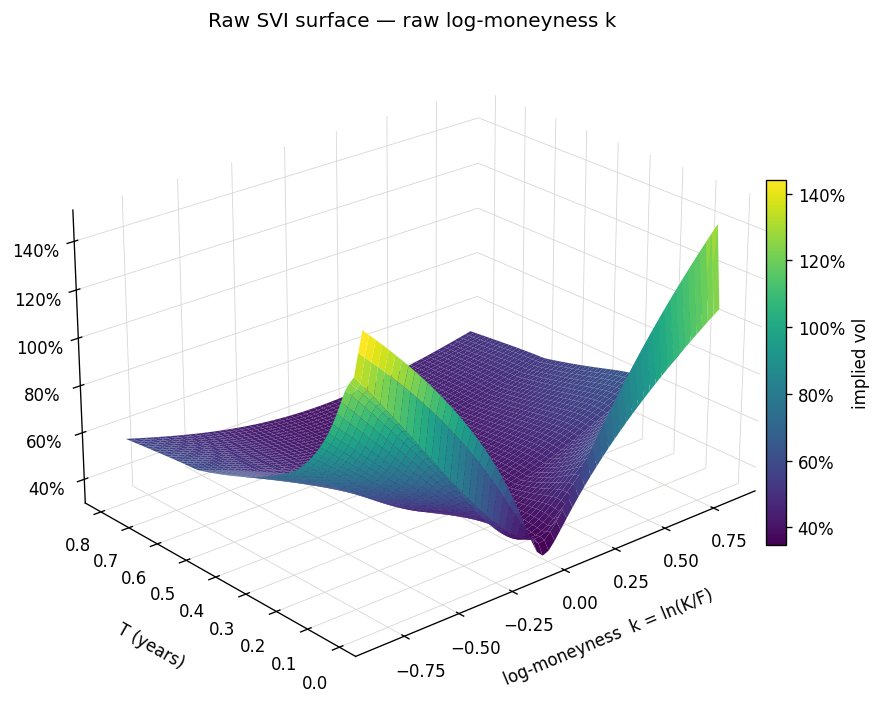

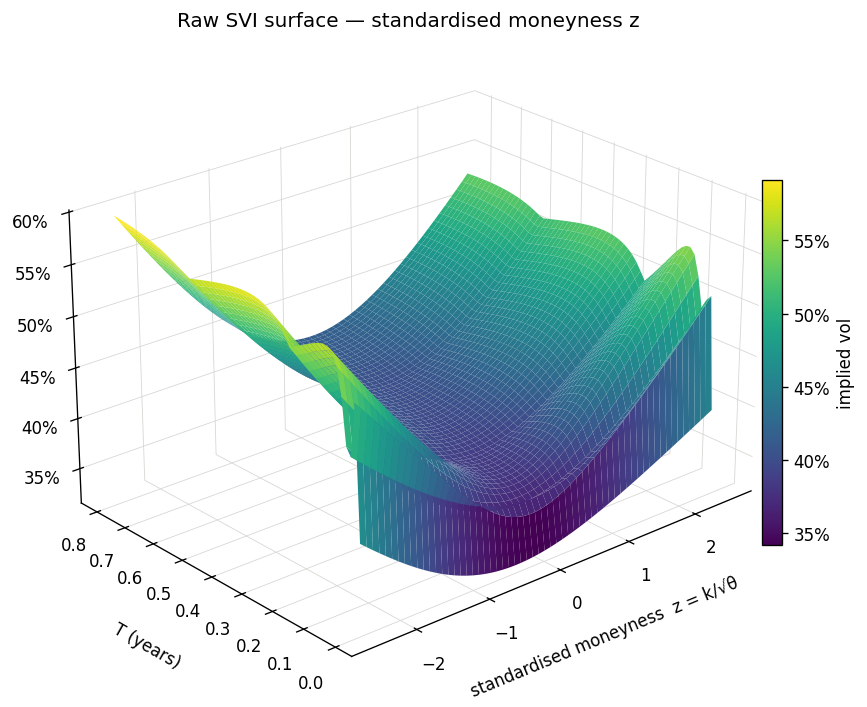

In [38]:
for axis, label in (('k', 'raw log-moneyness k'), ('z', 'standardised moneyness z')):
    display(ge.plot_vol_surface(
        surf, x_axis=axis, n_k=60, n_t=60, backend='matplotlib',
        k_range=PLOT_K_RANGE if axis == 'k' else None,
        t_range=PLOT_T_RANGE,
        title=f'Raw SVI surface — {label}'))

### 4.2 SSVI surface fitting (`fit_ssvi_surface`)

`fit_surface` above gives per-knot arbitrage-free + a
finite-grid empirical check between knots —  only as fine as the
sampled grid. 

`fit_ssvi_surface`: instead of independent
per-expiry raw-SVI fits stitched together, it fits the single
shared-`rho` to
the *whole* surface at once, then calls Corollary 4.1.
When that passes, the surface is arbitrage-free **everywhere** — every `(K, T)`, not just
the fitted knots or a grid.

In [39]:
ssvi_surf = None
for min_pts in (surface.MIN_POINTS_PER_SLICE, 10, 20, 30):
    try:
        ssvi_surf = surface.fit_ssvi_surface(quotes, min_points=min_pts)
        print(f'fit_ssvi_surface passed check_ssvi_no_static_arbitrage with min_points={min_pts}')
        break
    except arb.ArbitrageError as e:
        print(f'min_points={min_pts}: rejected ->')
        print(' ', e)

print('\n', ssvi_surf.ssvi_params)
print('theta_t (ATM total variance at each knot):', ssvi_surf.theta_values)
print(f"knots: T in [shortest fitted expiry, longest fitted expiry] = [{ssvi_surf.maturities[0]:.4f}, {ssvi_surf.maturities[-1]:.4f}]")

fit_ssvi_surface passed check_ssvi_no_static_arbitrage with min_points=5

 SSVIParams(rho=-0.08023959974102718, phi=<function phi_power_law.<locals>.phi at 0x717f562c2200>)
theta_t (ATM total variance at each knot): [0.000768 0.001165 0.001491 0.004466 0.006923 0.020815 0.033481 0.046028
 0.089638 0.139115]
knots: T in [shortest fitted expiry, longest fitted expiry] = [0.0074, 0.7991]


After fitting SSVI, the code numerically checks butterfly arbitrage (`g(k) >= 0`) at maturities between and beyond fitted knots, i.e at off-knots.
 SSVI’s Corollary 4.1 implies this should pass everywhere; this step is a practical sanity check.

In [40]:
off_knot_Ts = np.linspace(ssvi_surf.maturities[0], ssvi_surf.maturities[-1] * 1.5, 8)
h = 1e-4
worst_g = np.inf
for T_probe in off_knot_Ts:
    F_probe = np.interp(T_probe, ssvi_surf.maturities, ssvi_surf.forwards)

    def w_at(k_shift, F_probe=F_probe, T_probe=T_probe):
        K = F_probe * np.exp(arb.DEFAULT_K_GRID + k_shift)
        return ssvi_surf.implied_vol(K, T_probe) ** 2 * T_probe

    w, w_p, w_m = w_at(0.0), w_at(h), w_at(-h)
    dw = (w_p - w_m) / (2 * h)
    d2w = (w_p - 2 * w + w_m) / h ** 2
    g = (1 - arb.DEFAULT_K_GRID * dw / (2 * w)) ** 2 - (dw ** 2 / 4) * (1 / w + 0.25) + d2w / 2
    worst_g = min(worst_g, g.min())
    print(f'T={T_probe:.4f}: min g(k) = {g.min():.4f}')

print(f'\nworst g(k) across all off-knot probes: {worst_g:.4f} -> '
      f'{"butterfly arbitrage-free" if worst_g > -1e-6 else "VIOLATION"}')
assert worst_g > -1e-6



T=0.0074: min g(k) = 0.4614
T=0.1775: min g(k) = 0.4599
T=0.3477: min g(k) = 0.4581
T=0.5179: min g(k) = 0.4561
T=0.6881: min g(k) = 0.4539
T=0.8583: min g(k) = 0.4707
T=1.0285: min g(k) = 0.5176
T=1.1987: min g(k) = 0.5570

worst g(k) across all off-knot probes: 0.4539 -> butterfly arbitrage-free


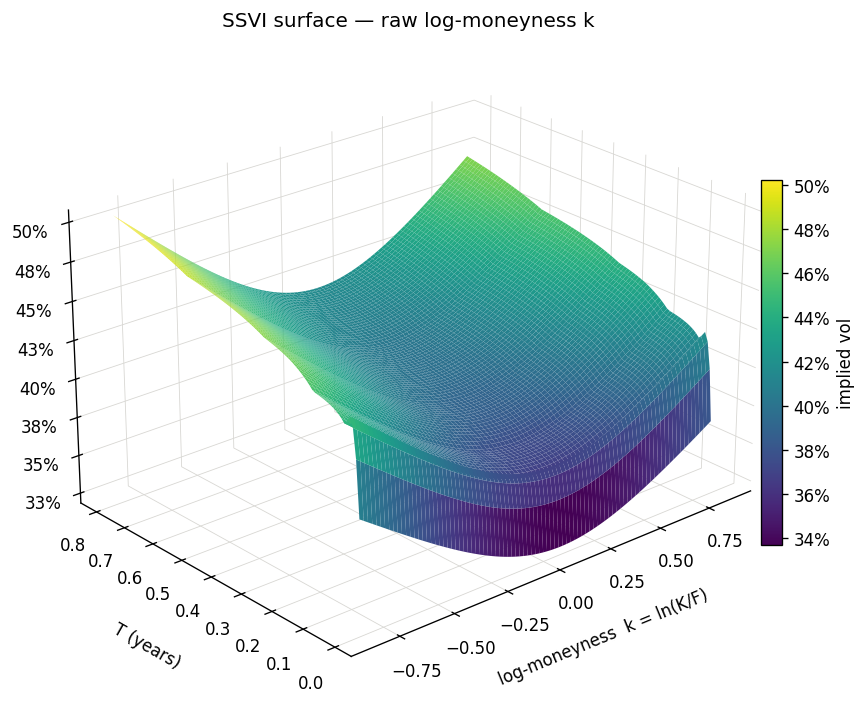

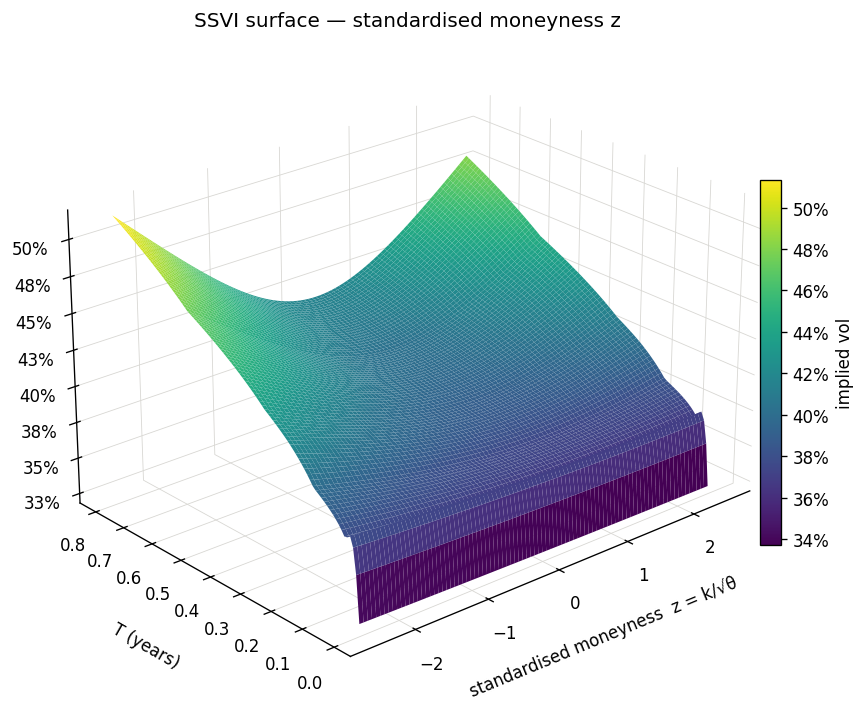

In [41]:
for axis, label in (('k', 'raw log-moneyness k'), ('z', 'standardised moneyness z')):
    display(ge.plot_vol_surface(
        ssvi_surf, x_axis=axis, n_k=90, n_t=90, backend='matplotlib',
        k_range=PLOT_K_RANGE if axis == 'k' else None,
        t_range=PLOT_T_RANGE,
        title=f'SSVI surface — {label}'))

### 4.3 — Global eSSVI (`global_essvi.py`) 

Above:`fit_surface`
gives a per-knot guarantee plus a finite-grid empirical check between knots;
`fit_ssvi_surface` gives a surface-wide one but spends a single `rho` on every maturity to
get it.

`global_essvi.calibrate` lets `rho` vary by maturity

Everything so far fits first and
validates afterwards, so there is always an admissible region the optimizer can leave.
The paper instead reparametrizes the admissible set itself as an open
hyperrectangle

```
rho_i ∈ ]−1,1[ ,  theta_1 ∈ ]0,∞[ ,  a_i ∈ ]0,∞[ ,  c_i ∈ ]0,1[ for i = 1,...,N
```

Proposition 3.1: every point of the box lands on an
arbitrage-free surface. So the calibration is an ordinary box-constrained least-squares
problem, there is no boundary to police, and `check_no_arbitrage` below is a sanity check.

In [42]:
essvi_result = ge.calibrate(**ge.chain_to_calibration_inputs(quotes), max_nfev=20000)
essvi_surf = essvi_result.surface
print(essvi_result)
print(f'converged: {essvi_result.success} -- {essvi_result.opt_result.message}')

pd.DataFrame({
    'T': essvi_surf.maturities,
    'forward': essvi_surf.forwards,
    'theta': [s.theta for s in essvi_surf.slices],
    'rho': [s.rho for s in essvi_surf.slices],
    'psi': [s.psi for s in essvi_surf.slices],
    'ATM vol': [essvi_surf.implied_vol(F, T)
                for F, T in zip(essvi_surf.forwards, essvi_surf.maturities)],
}).round(5)

CalibrationResult(success=True, n_quotes=282, weighted_rmse=30.3883, GlobalESSVISurface(N=10, T=[0.0074, 0.0101, 0.0128, 0.032, 0.0512, 0.1471, 0.2238, 0.3005, 0.5498, 0.7991]))
converged: True -- `ftol` termination condition is satisfied.


,T,forward,theta,rho,psi,ATM vol
0,0.00735,79637.830,0.00076,0.09007,0.01846,0.32219
1,0.01009,79644.320,0.00116,0.11378,0.02290,0.33956
2,0.01283,79645.645,0.00160,0.12728,0.02754,0.35358
3,0.03201,79708.000,0.00449,0.05451,0.04845,0.37448
4,0.05119,79754.830,0.00695,0.06544,0.06385,0.36861
5,0.14708,80098.620,0.02057,0.00624,0.12035,0.37399
6,0.22379,80414.860,0.03348,-0.02113,0.14594,0.38677
7,0.30050,80739.310,0.04575,-0.07226,0.18087,0.39020
8,0.54982,81655.540,0.08930,-0.06780,0.24787,0.40302
9,0.79913,82606.780,0.13893,-0.07248,0.30620,0.41696


In [43]:
t_probe = np.geomspace(essvi_surf.maturities[0] * 0.2, essvi_surf.maturities[-1] * 3.0, 300)
ge.check_no_arbitrage(essvi_surf, t_grid=t_probe)
print(f'check_no_arbitrage passed over {len(t_probe)} maturities in '
      f'[{t_probe[0]:.4f}, {t_probe[-1]:.2f}]y')

worst_g = min(arb.g_function(arb.DEFAULT_K_GRID,
                             ge.essvi_slice_to_raw_svi(essvi_surf.slice_at(t))).min()
              for t in t_probe)
print(f'worst min g(k) anywhere on that range: {worst_g:.4f}  (> 0 => no butterfly arbitrage)')

check_no_arbitrage passed over 300 maturities in [0.0015, 2.40]y
worst min g(k) anywhere on that range: 0.2623  (> 0 => no butterfly arbitrage)


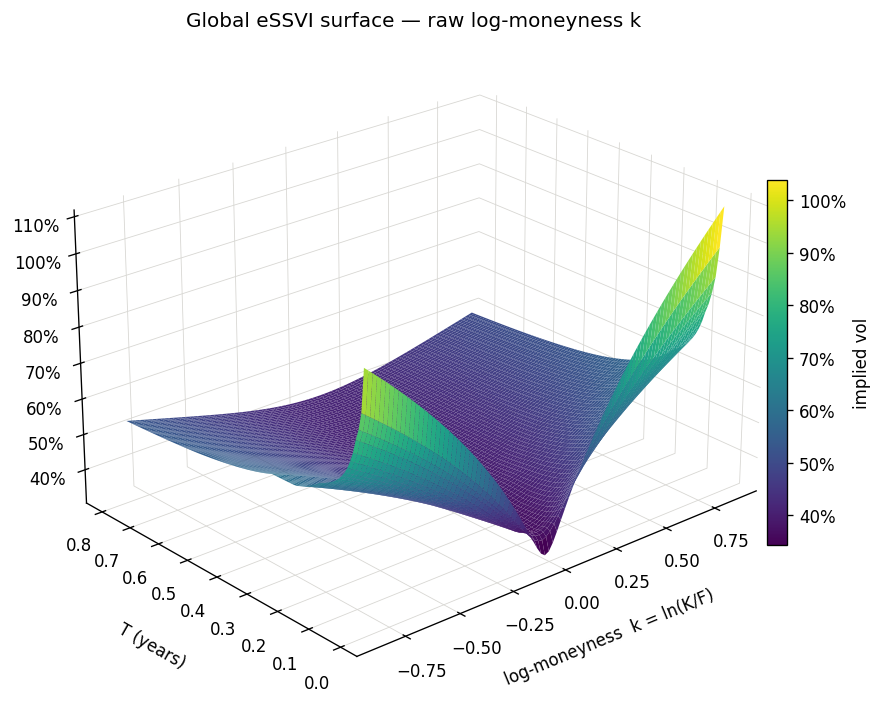

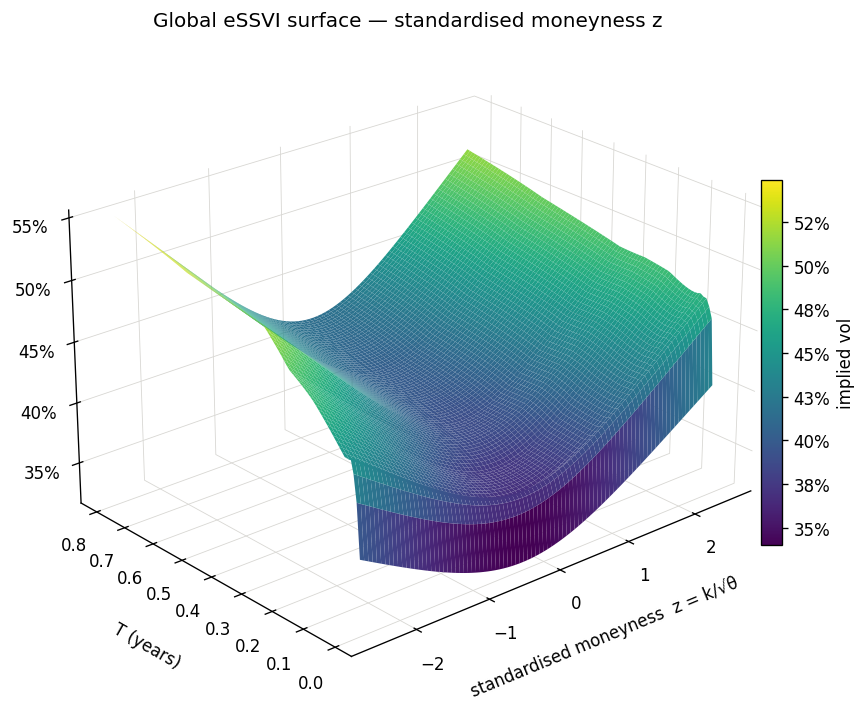

In [44]:
# same k window, same maturity span as the other two surfaces
for axis, label in (('k', 'raw log-moneyness k'), ('z', 'standardised moneyness z')):
    display(ge.plot_vol_surface(
        essvi_surf, x_axis=axis, n_k=90, n_t=90, backend='matplotlib',
        k_range=PLOT_K_RANGE if axis == 'k' else None,
        t_range=PLOT_T_RANGE,
        title=f'Global eSSVI surface — {label}'))

### 4.4 Benchmark — all three surfaces, one quote set, one metric

4.1, 4.2 and 4.3 each fitted and plotted a surface in isolation. This is the only section
they are compared, and all three were fitted to the same `quotes` from the top of Step 4. For each one: ask the model for its implied vol at that strike/maturity, subtract the market's own implied vol, take the absolute value. That gives the model's error, in vol points, on every single quote.

For example: "median 0.15%" means that where the market says 40.00%, the model says ~40.15%. So 0.15% here means 0.15 percentage points of volatility, not
15%.


Every model is queried at **all** $n$ quotes regardless of
whether it has a real fit at that maturity; if it skipped an expiry, it's still
interpolating or extrapolating across the gap to answer, and that guess is scored exactly
like every other quote. The `expiries fitted` column (e.g. 9 vs. 10) shows when this is
happening.

------

**The method: half the market's own bid-ask, converted into vol points.** A price error
in dollars and a vol error in vol points aren't directly comparable, so the market's bid-ask
spread has to be converted from price space into vol space before it can be used as a
benchmark. The conversion uses **vega**
$$
\text{half\_spread}_i = \frac{(\text{ask}_i - \text{bid}_i)/2}{\text{vega}_i}
$$

Dividing a dollar amount by a dollars-per-vol-point quantity leaves vol points. This is computed **per quote**, not once globally: an ATM option and a deep-wing option
have very different vega, so the same dollar-wide spread implies a very different vol-point
spread depending on where on the smile the quote sits. In code, this is the `HALF_SPREAD`
array — one value per row of `quotes`.

The market does not quote one true vol, it
quotes a bid and an ask, i.e. a *range* it's willing to trade at. A model landing inside
$[\sigma^{\text{market}}_i - \text{half\_spread}_i,\ \sigma^{\text{market}}_i +
\text{half\_spread}_i]$ is indistinguishable from correct. Below that band is not extractable signal, only quote-to-quote noise.

In [45]:
results = [
    benchmark('SVI + interpolate', surf, 5 * len(surf.maturities)),
    benchmark('SSVI', ssvi_surf, len(ssvi_surf.maturities) + 3),
    benchmark('Global eSSVI', essvi_surf, 3 * len(essvi_surf)),
]

print(f"benchmark: median market half bid-ask = {np.median(HALF_SPREAD):.3%} of vol")
pd.DataFrame(results).set_index('model').style.format({
    'median |dvol|': '{:.3%}', 'mean': '{:.3%}', 'p90': '{:.3%}',
    'inside bid-ask': '{:.0%}'})

benchmark: median market half bid-ask = 0.426% of vol


,params,expiries fitted,median |dvol|,mean,p90,inside bid-ask
model,,,,,,
SVI + interpolate,40,8,0.150%,0.618%,2.112%,71%
SSVI,13,10,1.012%,2.057%,5.389%,32%
Global eSSVI,30,10,0.156%,0.348%,0.523%,88%


**Reading the table's columns.** Sort the $n$ per-quote errors from smallest to largest,
$e_{(1)} \le e_{(2)} \le \dots \le e_{(n)}$:

- **median** — the middle value
- **mean** — `mean` sitting well
  above `median` is itself a signal that the errors are not evenly spread — there's a tail
  of quotes fit much worse than the typical one.
- **p90**  — the error at sorted position $\text{position} = 0.9 \times (n-1)$: $p{90} = e{(\text{position})}$, the value below which 90% of the $n$ quotes fall. Answers "how bad does it get before I've excluded 9 out of every 10 quotes". Sort all $n$ errors smallest to largest and walk up to that position: roughly $0.9n$ quotes sit at or below it, the remaining $0.1n$ are worse.   Concretely, if `p90 = 0.70%` means 90% of quotes are fitted to within 0.70 vol points, and
  the worst 10% are above that.
- **inside bid-ask** — $\frac{1}{n}\sum_i \mathbb{1}[\,e_i \le \text{half\_spread}_i\,]$,
  the **fraction of quotes where the model's error is smaller than that specific quote's own
  half bid-ask. This is the column that actually matters: it's the only one measured
  against the market's own precision**.

## Pricing off the surface


In [46]:
def _forward_at(surf_obj, T):
    Ts = np.asarray(surf_obj.maturities, dtype=float)
    Fs = np.asarray(surf_obj.forwards, dtype=float)
    T_clamped = np.clip(T, Ts[0], Ts[-1])
    return float(np.exp(np.interp(T_clamped, Ts, np.log(Fs))))


def theoretical_price(surf_obj, K, T, option_type):
    F = _forward_at(surf_obj, T)
    iv_KT = surf_obj.implied_vol(K, T)
    price = bs.price(F, K, T, 0.0, 0.0, iv_KT, option_type)
    return price, iv_KT, F


MODELS = [('SVI', surf), ('SSVI', ssvi_surf), ('eSSVI', essvi_surf)]

# price an on-grid ATM straddle at the nearest fitted expiry, off the SVI surface
K_atm = surf.forwards[0]
T0 = surf.maturities[0]
call_px, atm_iv, F0 = theoretical_price(surf, K_atm, T0, 'C')
put_px, _, _ = theoretical_price(surf, K_atm, T0, 'P')
print(f"T={T0:.4f}  F={F0:.2f}  ATM iv={atm_iv:.4f}")
print(f"ATM call = {call_px:.2f}   ATM put = {put_px:.2f}   straddle = {call_px + put_px:.2f}")

strikes_demo = surf.forwards[0] * np.array([0.85, 0.95, 1.0, 1.05, 1.15])
T_demo = 0.5 * (surf.maturities[0] + surf.maturities[1]) if len(surf.maturities) > 1 else surf.maturities[0]
otype_demo = np.where(strikes_demo >= surf.forwards[0], 'C', 'P')

rows = []
for K_i, otype_i in zip(strikes_demo, otype_demo):
    row = {'strike': K_i, 'type': otype_i, 'T': T_demo}
    for name, s in MODELS:
        price_i, iv_i, F_i = theoretical_price(s, K_i, T_demo, otype_i)
        row['forward'] = F_i 
        row[f'theo price ({name})'] = price_i
    rows.append(row)

pd.DataFrame(rows)

T=0.0074  F=79637.83  ATM iv=0.3232
ATM call = 880.27   ATM put = 880.27   straddle = 1760.55


,strike,type,T,forward,theo price (SVI),theo price (SSVI),theo price (eSSVI)
0,67692.1555,P,0.008721,79641.074934,3.4889480464428573,6.230610073531748e-05,0.11491780176389987
1,75655.9385,P,0.008721,79641.074934,77.67433195805006,50.74534289141866,68.40474125592573
2,79637.8300,C,0.008721,79641.074934,989.3020043082652,989.3585661030229,987.60647977607
3,83619.7215,C,0.008721,79641.074934,114.63766588701765,62.830704777370556,113.63211209222482
4,91583.5045,C,0.008721,79641.074934,1.9431014493556518,0.0017892610951090737,1.648129678806356
